tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


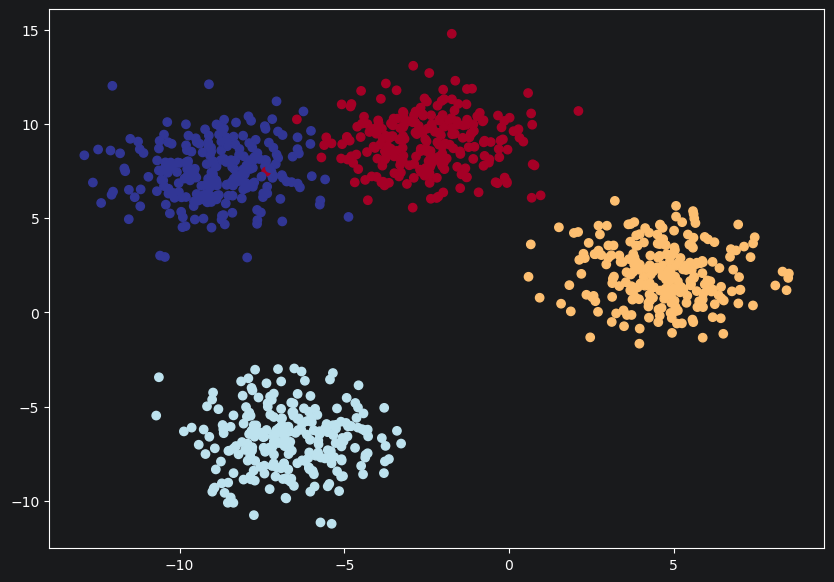

In [1]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [2]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from torch import nn

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [4]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1) # exercise: try changing the learning rate here and seeing what happens to the model's performance

In [5]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[-0.6324,  1.4943,  0.2957, -2.0512],
        [-1.3650,  1.0401, -0.1591, -1.4472],
        [-0.0141, -2.1759, -1.2087,  3.0872],
        [-0.3189, -1.2141, -0.8619,  1.7351],
        [-1.1965,  0.6432, -0.2881, -0.8875]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [6]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [12]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7400,  1.5799,  0.2998, -2.1747],
        [-1.3041, -0.1379, -0.6877,  0.1967],
        [-0.0459, -1.6742, -0.9856,  2.3870],
        [-0.4971,  1.0172,  0.1183, -1.3810],
        [-1.3452,  1.5132,  0.0678, -2.1056]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.0702, 0.7144, 0.1986, 0.0167],
        [0.0948, 0.3043, 0.1756, 0.4253],
        [0.0771, 0.0151, 0.0301, 0.8777],
        [0.1280, 0.5821, 0.2369, 0.0529],
        [0.0435, 0.7577, 0.1785, 0.0203]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [10]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[:5], dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SumBackward1>)

In [14]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.0702, 0.7144, 0.1986, 0.0167], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(1, device='cuda:0')


In [17]:
from helper_functions import accuracy_fn

# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.84789, Acc: 44.00% | Test Loss: 0.75636, Test Acc: 70.50%
Epoch: 10 | Loss: 0.14059, Acc: 99.25% | Test Loss: 0.12809, Test Acc: 99.50%
Epoch: 20 | Loss: 0.08019, Acc: 99.25% | Test Loss: 0.07240, Test Acc: 99.50%
Epoch: 30 | Loss: 0.05947, Acc: 99.25% | Test Loss: 0.05191, Test Acc: 99.50%
Epoch: 40 | Loss: 0.04927, Acc: 99.25% | Test Loss: 0.04149, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04329, Acc: 99.25% | Test Loss: 0.03527, Test Acc: 99.50%
Epoch: 60 | Loss: 0.03940, Acc: 99.25% | Test Loss: 0.03115, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03669, Acc: 99.25% | Test Loss: 0.02824, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03471, Acc: 99.25% | Test Loss: 0.02608, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03320, Acc: 99.25% | Test Loss: 0.02441, Test Acc: 99.50%


In [18]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[  5.6248,  10.7048, -11.5374,  -7.7757],
        [  3.3778, -10.2909,   1.5205,   9.0668],
        [-10.9383, -13.0680,  17.0918,   8.5537],
        [  1.9027,   7.7087,  -6.3150,  -6.0372],
        [  9.6098,   4.5948, -12.3185,  -1.9675],
        [  3.7279, -12.9540,   2.5495,  11.3272],
        [-11.0085, -10.1532,  15.6564,   6.1409],
        [  7.7110,   0.6334,  -8.3984,   0.9220],
        [-11.6816, -18.0184,  20.3815,  12.4832],
        [  8.2374,   2.0623,  -9.6558,  -0.1512]], device='cuda:0')